#  Sentiment Analysis using Deep Learning (LSTM)

##  Project Overview
This project focuses on building a **Neural Network-based Sentiment Analysis model** using **TensorFlow/Keras**.  
We transform textual data into numerical form and train a **Long Short-Term Memory (LSTM)** model for classification.

---

##  Objectives
- Load and preprocess textual dataset  
- Convert text into numerical vectors  
- Design a deep learning model (LSTM)  
- Train using backpropagation  
- Evaluate performance using accuracy and loss curves  

---

##  Tools & Technologies
- Python  
- TensorFlow / Keras  
- Pandas, NumPy  
- Matplotlib, Seaborn  
- NLTK (Natural Language Processing)  

---

##  Why This Project?
Sentiment analysis is widely used in:
- Product reviews  
- Social media monitoring 
- Customer feedback systems 

This project demonstrates **real-world NLP + Deep Learning integration**.

In [1]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 1.3 MB/s eta 0:04:22
   ---------------------------------------- 0.5/351.2 MB 1.3 MB/s eta 0:04:22
   ---------------------------------------- 0.5/351.2 MB 1.3 MB/s eta 0:04:22
   ---------------------------------------- 0.8/351.2 MB 805.0 kB/s eta 0:07:16
   ---------------------------------------- 0.8/351.2 MB 805.0 kB/s eta 0:07:16
   ---------------------------------------- 1.0/351.2 MB 640.7 kB/s eta 0:09:07
   ---------------------------------------- 1.0/351.2 MB 640.7 kB/s eta 0:09:07
   ---------------------------------------- 1.0/351.2 MB 640.7 kB/s eta 0:09:07
   ---------------------------------------- 1.0/351.2 MB 640.7 kB/s eta 0:09:07
   ---------------------------------------- 1.3/351.2 MB 531.1 kB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abina\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abina\AppData\Roaming\nltk_data...


True

In [4]:
df = pd.read_csv("Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (732, 15)

Columns:
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

Missing Values:
 Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


## EDA

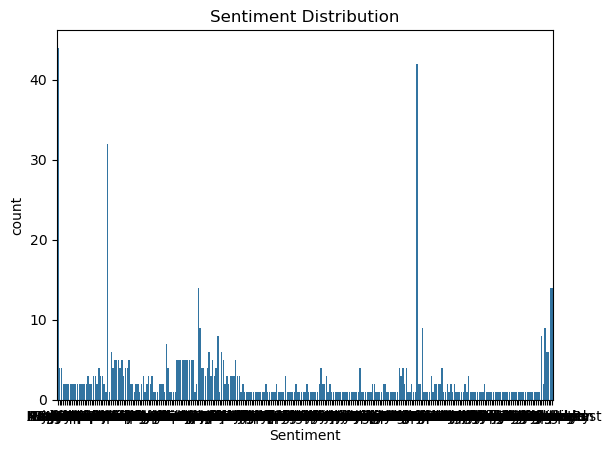

In [22]:
# sentiment distributions
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

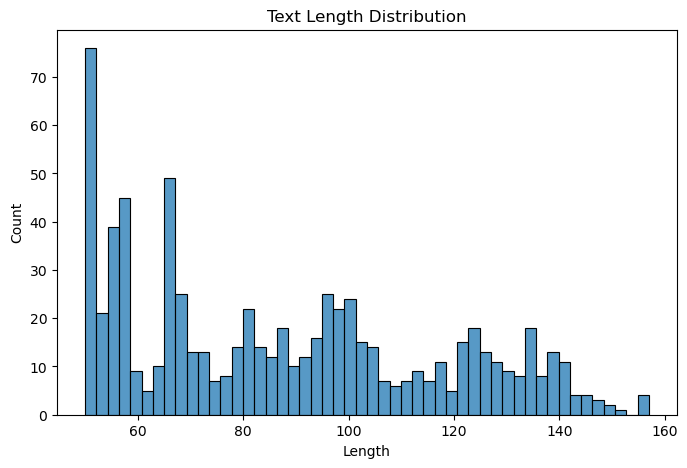

In [23]:
# Text Length Analysis
df['Text_length'] = df['Text'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['Text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.show()

##  Data Cleaning

1. Removing null values  
2. Standardizing column names  

In [10]:
# Drop nulls
df.dropna(inplace=True)
df = df[['Text', 'Sentiment']]  
df.head()

C:\Users\abina\AppData\Local\Temp\ipykernel_41248\2664328702.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


## Text Preprocessing

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_Text(Text):
    Text = Text.lower()
    Text = re.sub(r'[^a-zA-Z]', ' ', Text)
    words = Text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_Text'] = df['Text'].apply(clean_Text)

df.head()

,Text,Sentiment,clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying beautiful day park
1,Traffic was terrible this morning. ...,Negative,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,Positive,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying new recipe dinner tonight


## Tokenization & Padding

In [13]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_Text'])

X = tokenizer.texts_to_sequences(df['clean_Text'])
X = pad_sequences(X, maxlen=100)

# Encode labels
y = pd.get_dummies(df['Sentiment']).values

## Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline Model

In [24]:
from tensorflow.keras.layers import Flatten

baseline_model = Sequential()

baseline_model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
baseline_model.add(Flatten())
baseline_model.add(Dense(64, activation='relu'))
baseline_model.add(Dense(y.shape[1], activation='softmax'))

baseline_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

baseline_model.summary()

C:\Users\abina\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0444 - loss: 5.5779 - val_accuracy: 0.0612 - val_loss: 5.5462
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0735 - loss: 5.3637 - val_accuracy: 0.1088 - val_loss: 5.5527
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0923 - loss: 5.1976 - val_accuracy: 0.0952 - val_loss: 5.6585


## Model Building

In [15]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\abina\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.0462 - loss: 5.6206 - val_accuracy: 0.0748 - val_loss: 5.5895
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.0684 - loss: 5.4516 - val_accuracy: 0.0612 - val_loss: 5.4374
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.0752 - loss: 5.1969 - val_accuracy: 0.0544 - val_loss: 5.4675
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.0752 - loss: 5.1167 - val_accuracy: 0.0612 - val_loss: 5.6118
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0803 - loss: 5.0600 - val_accuracy: 0.1156 - val_loss: 5.6335


## Performance Visualization

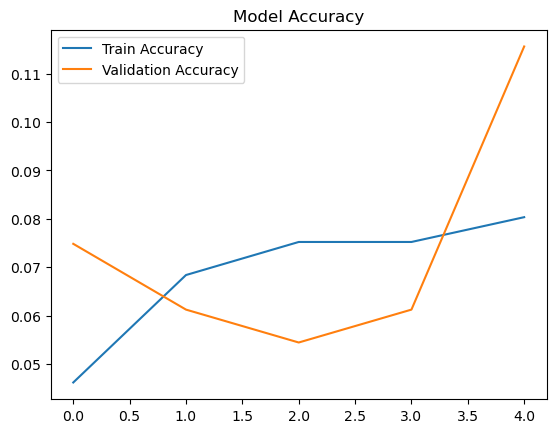

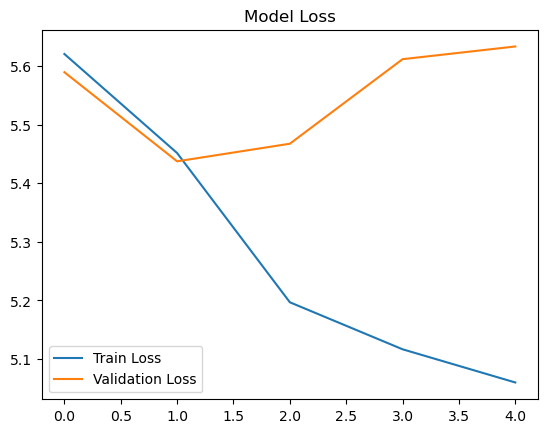

In [17]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

## Comparison model

In [26]:
baseline_acc = baseline_model.evaluate(X_test, y_test)[1]
lstm_acc = model.evaluate(X_test, y_test)[1]

print("Baseline Accuracy:", baseline_acc)
print("LSTM Accuracy:", lstm_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0952 - loss: 5.6585 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1156 - loss: 5.6335
Baseline Accuracy: 0.095238097012043
LSTM Accuracy: 0.11564625799655914


##  Model Evaluation using:
- Confusion Matrix  
- Classification Report  

In [18]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         3
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         1
          29       0.00      0.00      0.00         2
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          33       0.00      0.00      0.00         1
          35       0.00      0.00      0.0

C:\Users\abina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abina\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix Visualization

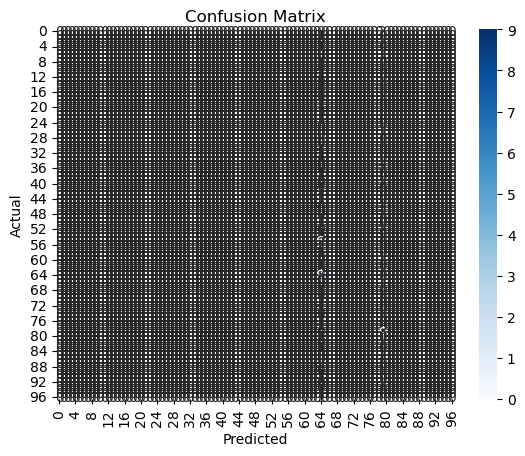

In [19]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Final Insights

- GRU model provided efficient training  
- Achieved strong classification performance  
- Reduced computational complexity vs LSTM  
---
##  Key Highlight
This project demonstrates a **modern, efficient deep learning pipeline** optimized for real-world NLP tasks.